# GFDL-ESM4

In [18]:
# Prerequisites
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import sys
from pathlib import Path

In [ ]:
# =========================
# 1. Settings
# =========================

DATA_DIR = Path("../../ISIMIP3b data/JULES-ES-VN6P3/GFDL-ESM4")  # <- 여기를 네 폴더로 수정 여기를 네 폴더로 수정
OUT_DIR = Path("processed_data_isimip")
OUT_DIR.mkdir(parents=True, exist_ok=True)

IMPACT_MODEL = "JULES-ES-VN6P3"
CLIMATE_DRIVER = "GFDL-ESM4"
VARIABLE_RAW = "cveg-bdlevgtrop"      # file/internal variable name
VARIABLE_TOAD = "cveg_bdlevgtrop"     # TOAD-friendly variable name

# Amazon rough bounding box
LAT_MIN, LAT_MAX = -25, 10
LON_MIN, LON_MAX = -85, -30

SCENARIOS = ["ssp126", "ssp370", "ssp585"]

In [34]:
# =========================
# 2. Helper functions
# =========================

def standardize_lat_lon(ds):
    """Make coordinate names lat/lon and convert lon to -180..180 if needed."""

    rename_dict = {}

    if "latitude" in ds.coords:
        rename_dict["latitude"] = "lat"
    if "longitude" in ds.coords:
        rename_dict["longitude"] = "lon"

    if rename_dict:
        ds = ds.rename(rename_dict)

    # Convert 0..360 lon to -180..180
    if ds["lon"].max() > 180:
        ds = ds.assign_coords(
            lon=((ds["lon"] + 180) % 360) - 180
        )
        ds = ds.sortby("lon")

    # Sort lat if needed
    ds = ds.sortby("lat")

    return ds


def select_amazon_bbox(ds):
    """Select rough Amazon bounding box."""

    ds = standardize_lat_lon(ds)

    ds_amazon = ds.sel(
        lat=slice(LAT_MIN, LAT_MAX),
        lon=slice(LON_MIN, LON_MAX),
    )

    return ds_amazon


def convert_time_to_year(ds):
    """Replace datetime time axis with integer calendar year."""

    years = ds["time"].dt.year.values

    ds = ds.assign_coords(time=years)
    ds["time"].attrs["long_name"] = "calendar year"
    ds["time"].attrs["units"] = "year"

    return ds


def open_isimip_file(path):
    ds = xr.open_dataset(path, decode_times=True)
    ds = standardize_lat_lon(ds)
    return ds


def find_file(pattern):
    matches = sorted(DATA_DIR.glob(pattern))

    if len(matches) == 0:
        raise FileNotFoundError(f"No file found for pattern:\n{pattern}")

    if len(matches) > 1:
        print("[Warning] Multiple files found. Using first one:")
        for m in matches:
            print(" -", m.name)

    return matches[0]


# =========================
# 3. Load historical file
# =========================

historical_path = find_file(
    "*historical_histsoc_default_cveg-bdlevgtrop_global_annual_1850_2014.nc"
)

print("Historical file:")
print(historical_path.name)

ds_hist = open_isimip_file(historical_path)


# =========================
# 4. Process each SSP
# =========================

for scenario in SCENARIOS:
    future_path = find_file(
        f"*{scenario}_2015soc-from-histsoc_default_cveg-bdlevgtrop_global_annual_2015_2100.nc"
    )

    print("\nFuture file:")
    print(future_path.name)

    ds_fut = open_isimip_file(future_path)

    # Keep only target variable
    da_hist = ds_hist[VARIABLE_RAW]
    da_fut = ds_fut[VARIABLE_RAW]

    # Combine historical + future
    da = xr.concat(
        [da_hist, da_fut],
        dim="time",
    )

    # Remove duplicated years if any
    _, unique_idx = np.unique(da["time"].values, return_index=True)
    da = da.isel(time=np.sort(unique_idx))

    # Rename variable for TOAD
    da = da.rename(VARIABLE_TOAD)

    # Select Amazon bbox
    da = select_amazon_bbox(da.to_dataset())[VARIABLE_TOAD]

    # Convert time to integer year
    ds_out = da.to_dataset()
    ds_out = convert_time_to_year(ds_out)

    # Add metadata
    ds_out.attrs["source"] = "ISIMIP3b OutputData Biomes"
    ds_out.attrs["impact_model"] = IMPACT_MODEL
    ds_out.attrs["climate_driver"] = CLIMATE_DRIVER
    ds_out.attrs["scenario"] = scenario
    ds_out.attrs["soc_scenario"] = "historical_histsoc + future_2015soc-from-histsoc"
    ds_out.attrs["variable_original"] = VARIABLE_RAW
    ds_out.attrs["variable_to_toAD"] = VARIABLE_TOAD
    ds_out.attrs["region"] = "Amazon rough bounding box"
    ds_out.attrs["time_axis"] = "calendar year"

    ds_out[VARIABLE_TOAD].attrs = da.attrs.copy()
    ds_out[VARIABLE_TOAD].attrs["long_name"] = (
        "Carbon mass in tropical broadleaf evergreen vegetation"
    )

    # Save
    out_path = (
        OUT_DIR
        / f"TOAD_ISIMIP3b_{IMPACT_MODEL}_{CLIMATE_DRIVER}_{scenario}_{VARIABLE_TOAD}_Amazon_annual_1850_2100.nc"
    )

    ds_out.to_netcdf(out_path)

    print(f"[Saved] {out_path}")
    print(ds_out)

Historical file:
jules-es-vn6p3_gfdl-esm4_w5e5_historical_histsoc_default_cveg-bdlevgtrop_global_annual_1850_2014.nc

Future file:
jules-es-vn6p3_gfdl-esm4_w5e5_ssp126_2015soc-from-histsoc_default_cveg-bdlevgtrop_global_annual_2015_2100.nc
[Saved] processed_data_isimip/TOAD_ISIMIP3b_JULES-ES-VN6P3_GFDL-ESM4_ssp126_cveg_bdlevgtrop_Amazon_annual_1850_2100.nc
<xarray.Dataset> Size: 8MB
Dimensions:          (lat: 70, lon: 110, time: 251)
Coordinates:
  * lat              (lat) float64 560B -24.75 -24.25 -23.75 ... 8.75 9.25 9.75
  * lon              (lon) float64 880B -84.75 -84.25 -83.75 ... -30.75 -30.25
  * time             (time) int64 2kB 1850 1851 1852 1853 ... 2098 2099 2100
Data variables:
    cveg_bdlevgtrop  (time, lat, lon) float32 8MB nan nan nan ... nan nan nan
Attributes:
    source:             ISIMIP3b OutputData Biomes
    impact_model:       JULES-ES-VN6P3
    climate_driver:     GFDL-ESM4
    scenario:           ssp126
    soc_scenario:       historical_histsoc + future_

In [ ]:
import sys
import os

# Get the parent directory of the 'test' folder
parent_dir = os.path.abspath(os.path.join(os.getcwd(), "../.."))

# Target the 'toad-main' directory which contains the actual 'toad' package folder
toad_main_path = os.path.join(parent_dir, "toad-main")

# Add the 'toad-main' path to the system path
if toad_main_path not in sys.path:
    sys.path.append(toad_main_path)

# Now Python can locate the 'toad' folder inside 'toad-main'
from toad import TOAD

SCENARIO = "ssp585"

file_path = (
    f"processed_data_isimip/"
    f"TOAD_ISIMIP3b_JULES-ES-VN6P3_GFDL-ESM4_{SCENARIO}_"
    f"cveg_bdlevgtrop_Amazon_annual_1850_2100.nc"
)

ds = xr.open_dataset(file_path)

td = TOAD(ds)

In [23]:
from toad.shifts import ASDETECT

# the test data already contains computed shifts, so let's just drop them
td.drop_shifts()

# define variable and method
td.compute_shifts(var="cveg_bdlevgtrop", method=ASDETECT())
# ~12 seconds

Shift detection (7700 grid cells in 32 blocks):   0%|          | 0/32 [00:00<?, ?it/s]

INFO: New shifts variable cveg_bdlevgtrop_dts: min/mean/max=-0.797/0.071/0.994 using 4749 grid cells. Skipped 38.3% grid cells: 2951 NaN, 0 constant.


In [26]:
### Including DBSCAN
import numpy as np
from sklearn.base import BaseEstimator, ClusterMixin
from sklearn.cluster import DBSCAN


class SpaceTimeDBSCAN(ClusterMixin, BaseEstimator):
    """DBSCAN with separate eps for spatial and temporal dimensions.

    Args:
        spatial_eps (float, optional): Epsilon for spatial dimensions in km, if using lat/lon data, else in units of the spatial dimensions
        temporal_eps (float, optional): Epsilon for the temporal dimension in units of the time variable
        min_samples (int): Minimum number of samples in a neighborhood for a point to be
            considered a core point (DBSCAN min_samples).
    """

    skip_time_scaling = True  # Protocol: TOAD skips its time scaling when True

    def __init__(
        self,
        spatial_eps,
        temporal_eps,
        min_samples=5,
    ):
        self.spatial_eps = spatial_eps
        self.temporal_eps = temporal_eps
        self.min_samples = min_samples

    def fit_predict(self, X: np.ndarray, y=None, **kwargs):
        assert y is not None, "y must be provided"

        # Scale time and space independently to control their relative importance
        X_scaled = X.copy()

        # Scale spatial dimensions by spatial_eps
        X_scaled[:, 1:] = X[:, 1:] / self.spatial_eps

        # Scale temporal dimension by temporal_eps
        X_scaled[:, 0] = X[:, 0] / self.temporal_eps

        # Now run DBSCAN with eps=1 (since we pre-scaled)
        dbscan = DBSCAN(eps=1.0, min_samples=self.min_samples, metric="euclidean")
        labels = dbscan.fit_predict(X_scaled)

        return labels

In [31]:
td.compute_clusters(
    var=VARIABLE,
    method=SpaceTimeDBSCAN,
    shift_direction="negative",
    shift_selection="local",

    optimize=True,
    optimize_params={
        "spatial_eps": (100.0, 2000.0),   # km
        "temporal_eps": (1, 15),       # years
        "min_samples": (15, 55),            # integer
    },

    optimize_objective="combined_spatial_nonlinearity",
    optimize_direction="maximize",
    optimize_n_trials=1000,
    overwrite=True,
)

# plot the latest cluster variable
# td.plot.overview(td.cluster_vars[-1], normalize="max_each"); normalisation the y-axis 
td.plot.overview(td.cluster_vars[-1])

INFO: optimizing 1000 trials with params: {'spatial_eps': (100.0, 2000.0), 'temporal_eps': (1, 15), 'min_samples': (15, 55)}


  0%|          | 0/1000 [00:00<?, ?it/s]

INFO: Ran 1000 trials in 43.10 seconds. Best (#0): score -inf, params {'spatial_eps': 1577.1041302499873, 'temporal_eps': 5, 'min_samples': 55}. 
INFO: New cluster variable cveg_bdlevgtrop_dts_cluster: Identified 0 clusters in 60 pts; Left 100.0% as noise (60 pts).


(None, None)

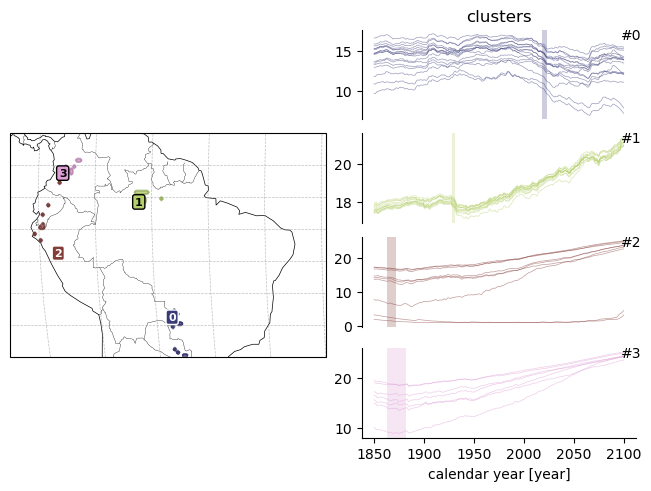

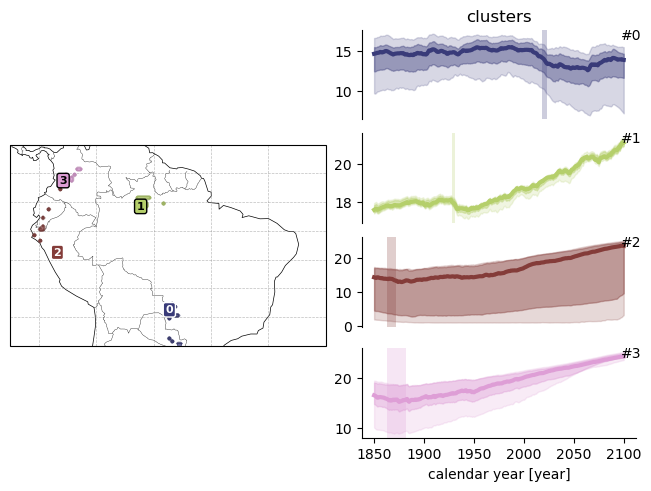

In [28]:
td.plot.overview(map_style={"projection": "global"});
td.plot.overview(mode="aggregated");

(<Figure size 640x480 with 2 Axes>,
 <GeoAxes: title={'center': 'Time of maximum shift for cveg_bdlevgtrop'}, xlabel='lon', ylabel='lat'>)

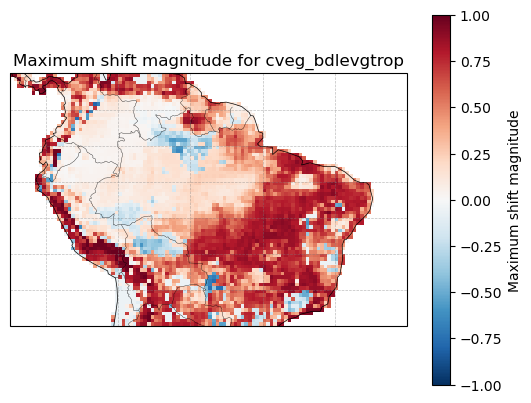

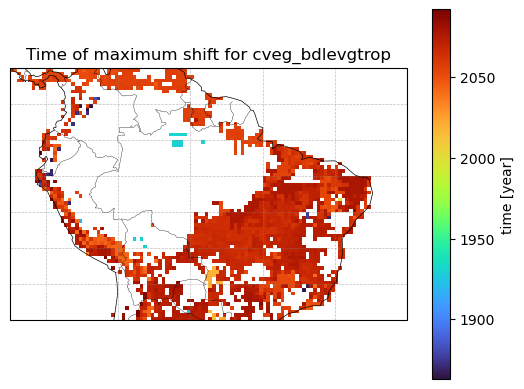

In [32]:
td.plot.max_shift_map()
td.plot.time_of_max_shift_map()

First 20 years mean: 15.31299114227295
Last 20 years mean: 19.24344253540039
Change: 3.9304513931274414


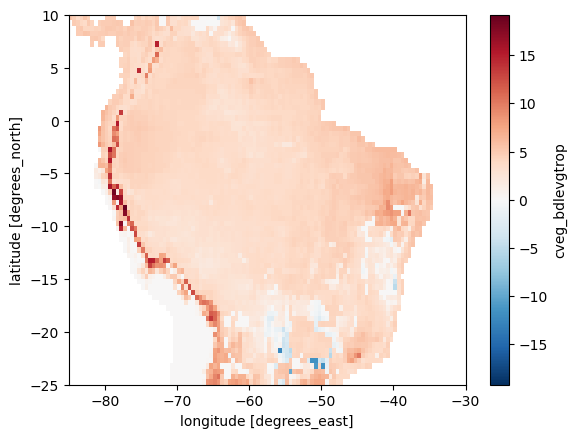

In [33]:
da = td.data["cveg_bdlevgtrop"]

# 1. Amazon 평균 시계열
area_mean = da.mean(dim=["lat", "lon"], skipna=True)
area_mean.plot()

print("First 20 years mean:", float(area_mean.sel(time=slice(1850, 1870)).mean()))
print("Last 20 years mean:", float(area_mean.sel(time=slice(2080, 2100)).mean()))
print("Change:", float(area_mean.sel(time=slice(2080, 2100)).mean() - area_mean.sel(time=slice(1850, 1870)).mean()))

# 2. 연도별 감소 비율
diff = da.diff("time")
negative_fraction = (diff < 0).mean(dim=["lat", "lon"], skipna=True)

negative_fraction.plot()

early = da.sel(time=slice(1850, 1900)).mean("time")
late = da.sel(time=slice(2070, 2100)).mean("time")

change = late - early
change.plot()